In [1]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Text Processing
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, FreqDist, ngrams
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.neighbors import NearestNeighbors

# Visualization
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

### Data Loading

In [2]:
df = pd.read_json("yelp_academic_dataset_business.json", lines = True)

In [3]:
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (150346, 14)


In [4]:
df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [5]:
df.dtypes

business_id      object
name             object
address          object
city             object
state            object
postal_code      object
latitude        float64
longitude       float64
stars           float64
review_count      int64
is_open           int64
attributes       object
categories       object
hours            object
dtype: object

### Data Cleaning

In [6]:
# Checking missing values
df.isnull().sum()

business_id         0
name                0
address             0
city                0
state               0
postal_code         0
latitude            0
longitude           0
stars               0
review_count        0
is_open             0
attributes      13744
categories        103
hours           23223
dtype: int64

* The essential columns required for the project: business_id, name, address, city, state, postal_code, latitude, longitude, stars, review_count, and is_open have 0 missing values.
* Other columns (attributes, categories, hours) that are not needed for analyis in this project have missing values.

Outliers before cleaning: 


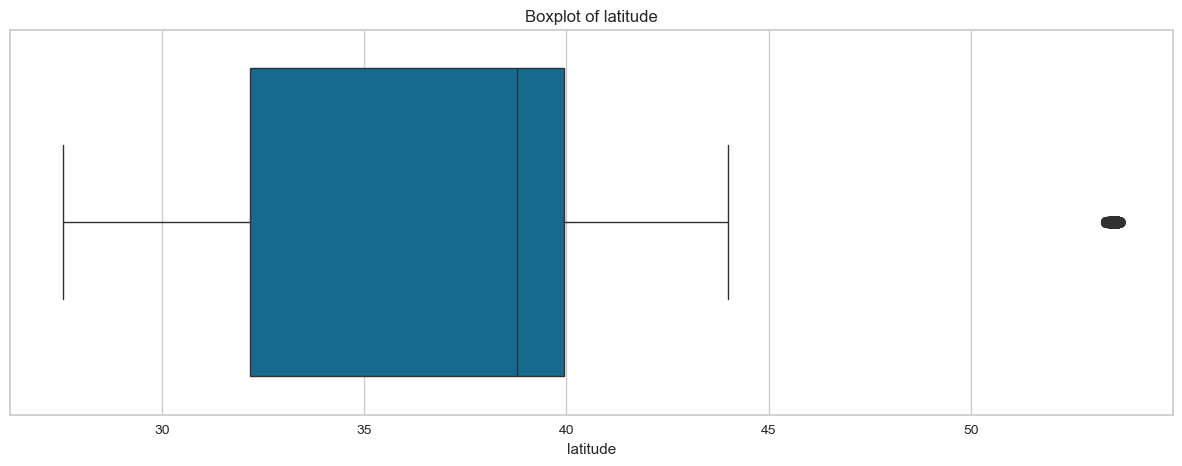

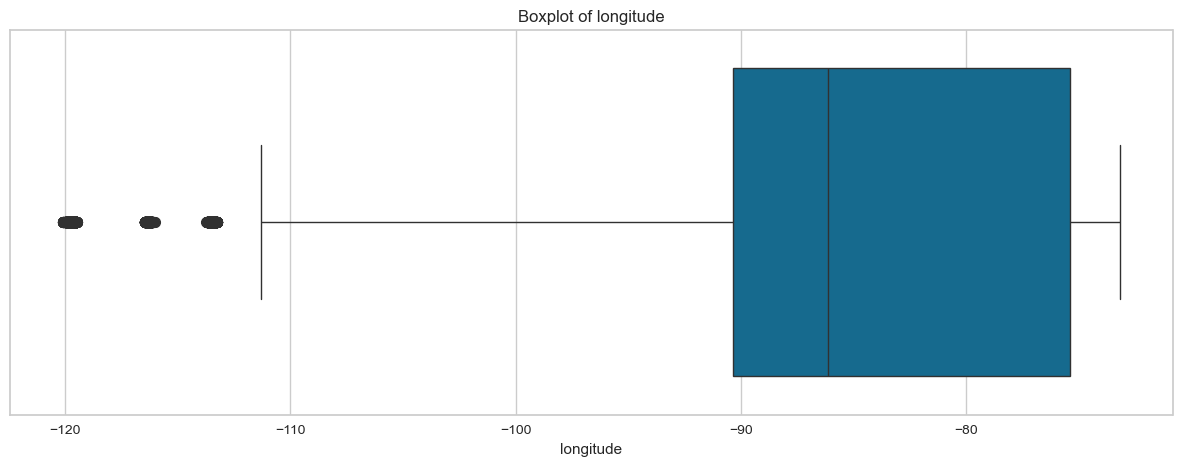

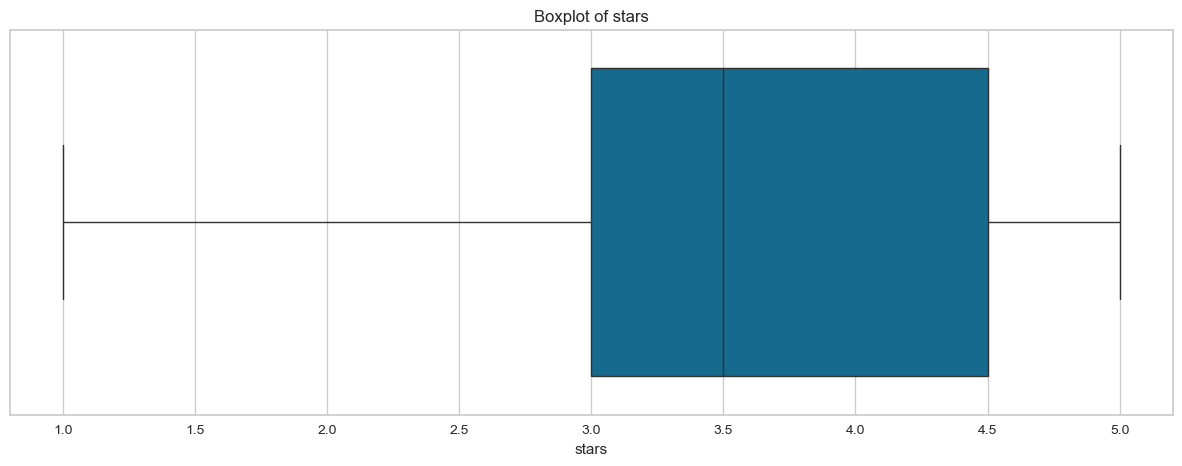

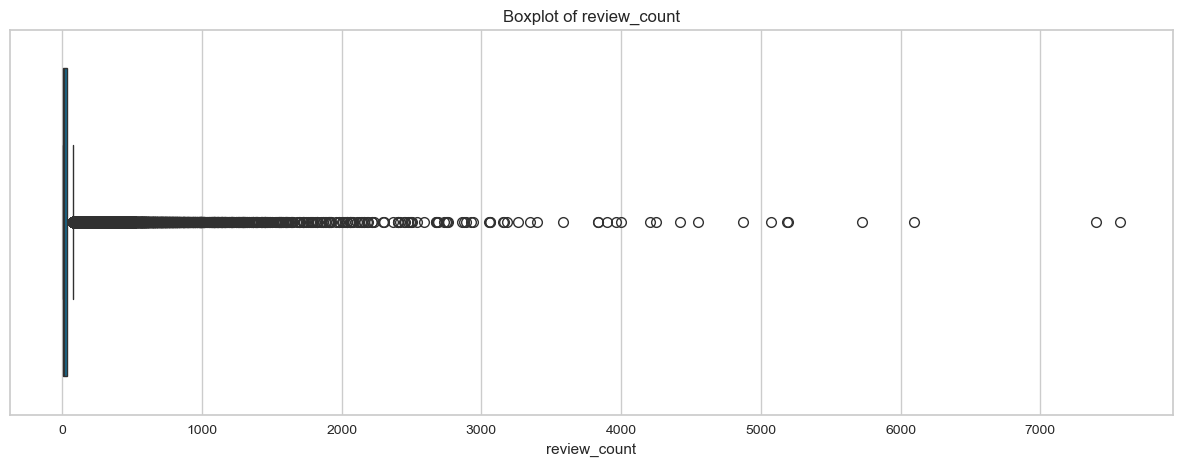

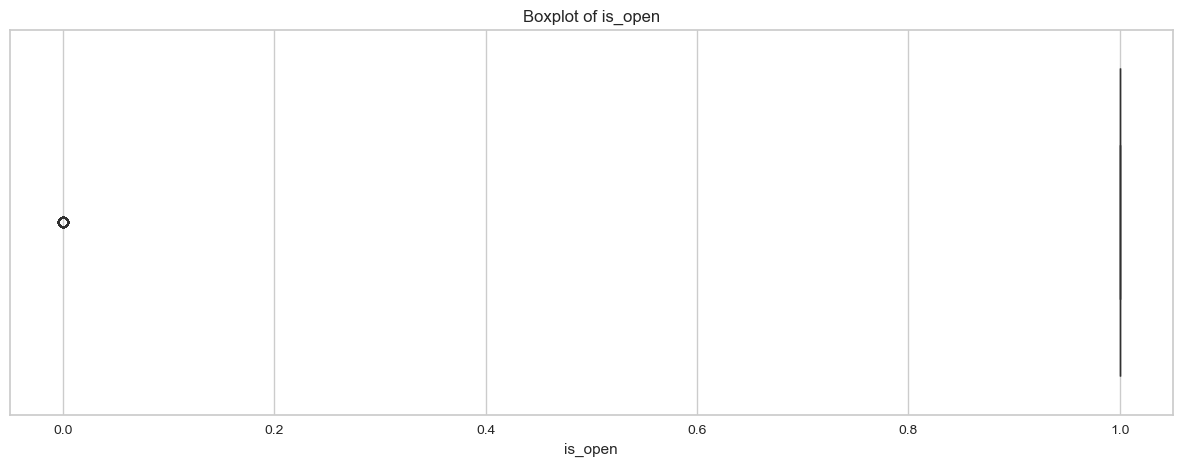

In [7]:
# Checking outliers for numerical columns (Before Cleaning)

print("Outliers before cleaning: ")

numerical_cols = ['latitude', 'longitude', 'stars', 'review_count', 'is_open']

for col in numerical_cols:
    plt.figure(figsize = (15,5))  # Creates a new window for each plot
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

* All the numerical columns do not have major outliers and look okay . 

In [8]:
df.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

In [9]:
df['name'].value_counts()

name
Starbucks                  724
McDonald's                 703
Dunkin'                    510
Subway                     459
Taco Bell                  365
                          ... 
San Roque Florist            1
Perfect Taste Grill          1
il Fustino                   1
Chong's Oriental Market      1
Sic Ink                      1
Name: count, Length: 114117, dtype: int64

In [10]:
df['address'].value_counts()

address
                           5127
160 N Gulph Rd               86
51 N 12th St                 55
1 Terminal Dr                52
4100 George J Bean Pkwy      46
                           ... 
20545 County Line Rd          1
4425 Concord Pike             1
8860 Pendleton Pike           1
9608 76 Avenue NW             1
238 Apollo Beach Blvd         1
Name: count, Length: 122844, dtype: int64

In [11]:
df['city'].value_counts()

city
Philadelphia      14569
Tucson             9250
Tampa              9050
Indianapolis       7540
Nashville          6971
                  ...  
Gentilly              1
pennsauken            1
Hamiltion             1
Newtown square        1
Apollo beach          1
Name: count, Length: 1416, dtype: int64

In [12]:
df['state'].value_counts()

state
PA     34039
FL     26330
TN     12056
IN     11247
MO     10913
LA      9924
AZ      9912
NJ      8536
NV      7715
AB      5573
CA      5203
ID      4467
DE      2265
IL      2145
TX         4
CO         3
WA         2
HI         2
MA         2
NC         1
UT         1
MT         1
MI         1
SD         1
XMS        1
VI         1
VT         1
Name: count, dtype: int64

In [13]:
df['postal_code'].value_counts()

postal_code
93101      1866
89502      1804
70130      1512
19103      1362
19107      1353
           ... 
46211         1
T5K 1C4       1
T6G 0W8       1
T5H 0R8       1
T5J 4X6       1
Name: count, Length: 3362, dtype: int64

* Columns other than the numerical ones also look fine as of now. If outliers are seen later, they would be dealt with then. 

In [14]:
df.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

### Exploratory Data Analysis (EDA)

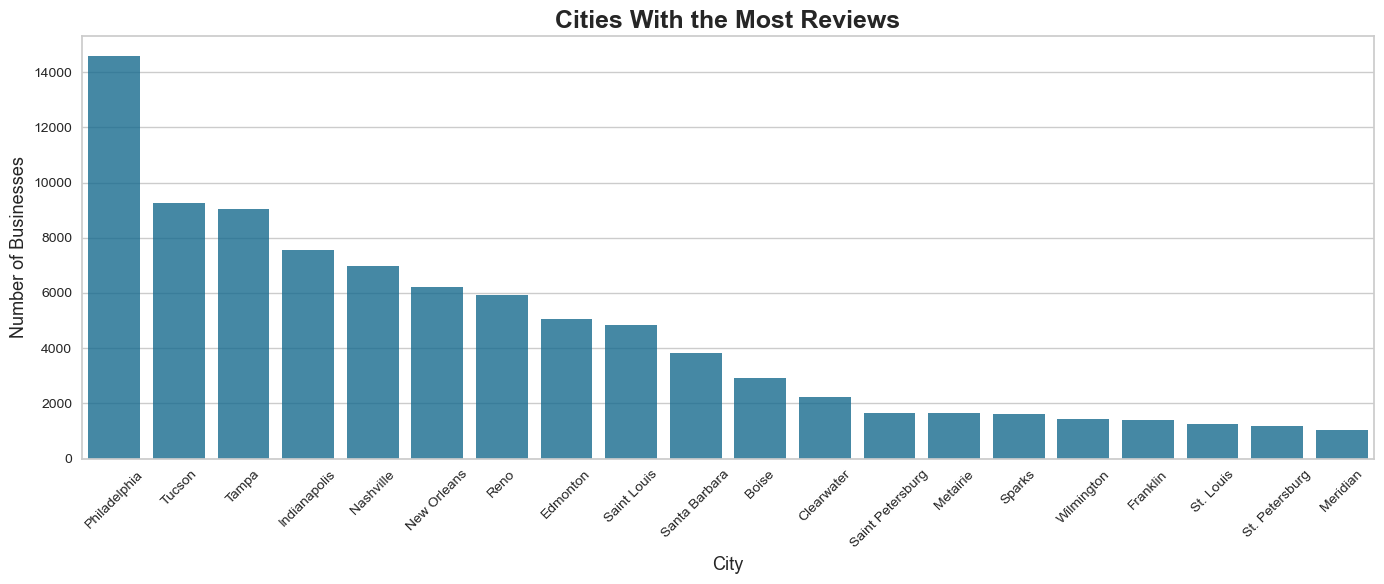

In [15]:
# Top Cities/Cities with the most reviews

x = df['city'].value_counts()
x = x.sort_values(ascending = False)
x = x.iloc[0:20]
plt.figure(figsize = (14, 6))
sns.barplot(x = x.index, y = x.values, alpha = 0.8)
plt.title("Cities With the Most Reviews", fontweight = 'bold', fontsize = 18)
locs, labels = plt.xticks()
plt.setp(labels, rotation=45)
plt.xlabel('City', fontsize = 13)
plt.ylabel('Number of Businesses', fontsize = 13)
plt.tight_layout()
plt.show()

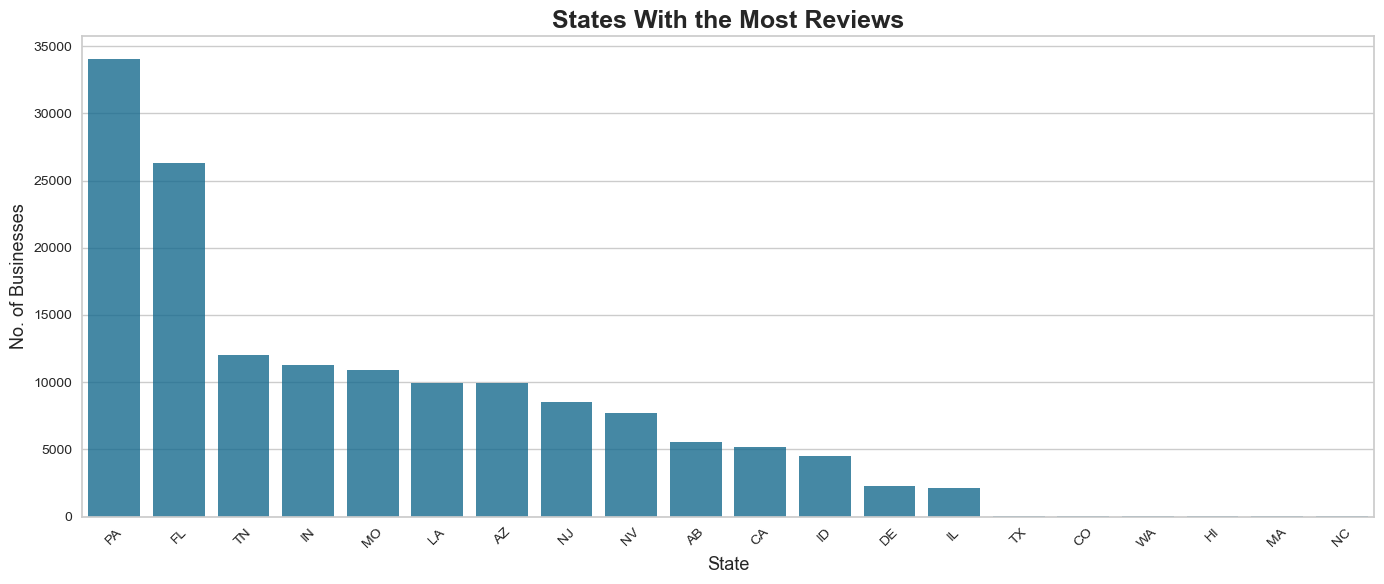

In [16]:
# Top States/States with the most reviews

x = df['state'].value_counts()
x = x.sort_values(ascending = False)
x = x.iloc[0:20]
plt.figure(figsize = (14, 6))
sns.barplot(x = x.index, y = x.values, alpha = 0.8)
plt.title("States With the Most Reviews", fontweight = 'bold', fontsize = 18)
locs, labels = plt.xticks()
plt.setp(labels, rotation=45)
plt.xlabel("State", fontsize = 13)
plt.ylabel("No. of Businesses", fontsize = 13)
plt.tight_layout()
plt.show()

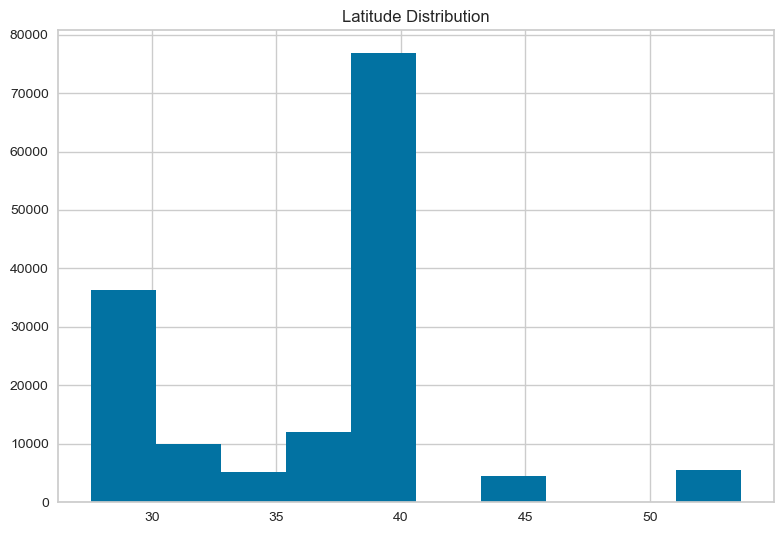

In [17]:
# Latitude Distribution

df['latitude'].hist()
plt.title("Latitude Distribution")
plt.tight_layout()
plt.show()

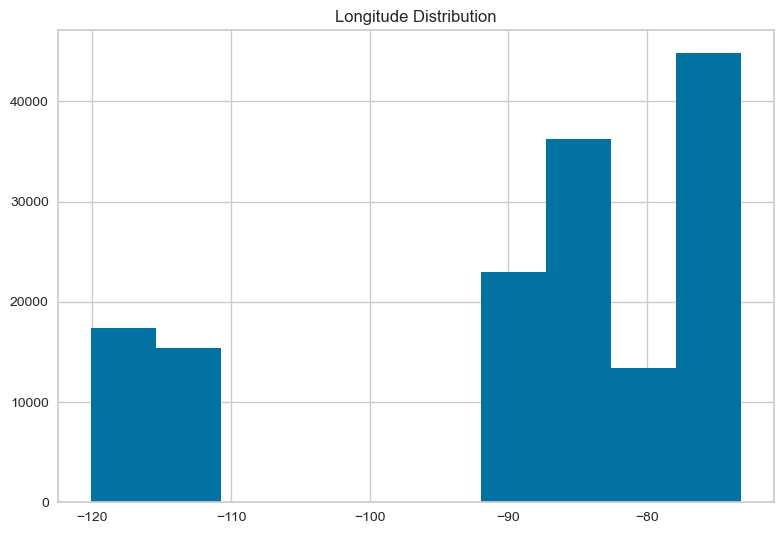

In [18]:
# Longitude Distribution

df['longitude'].hist()
plt.title("Longitude Distribution")
plt.tight_layout()
plt.show()

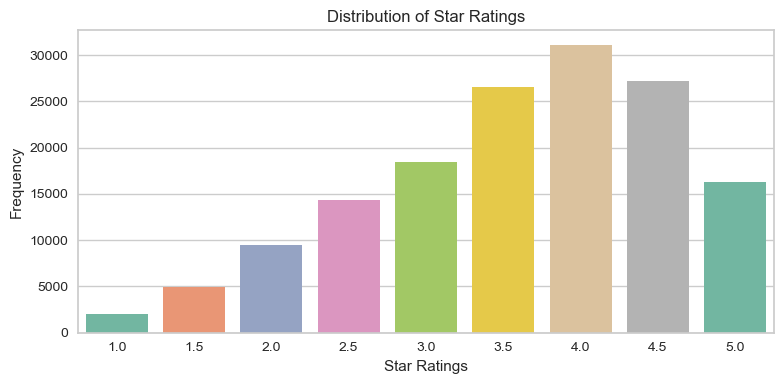

In [19]:
# Star Ratings Distribution

plt.figure(figsize = (8, 4))
sns.countplot(x = df['stars'], palette = 'Set2')
plt.title("Distribution of Star Ratings")
plt.xlabel("Star Ratings")
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

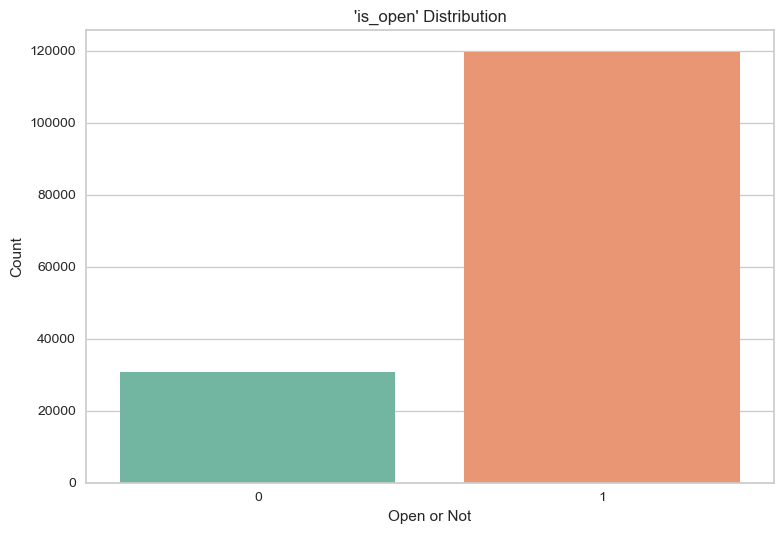

In [20]:
# 'is_open' Distribution

sns.countplot(x = df['is_open'], palette = 'Set2')
plt.title("'is_open' Distribution")
plt.xlabel("Open or Not")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

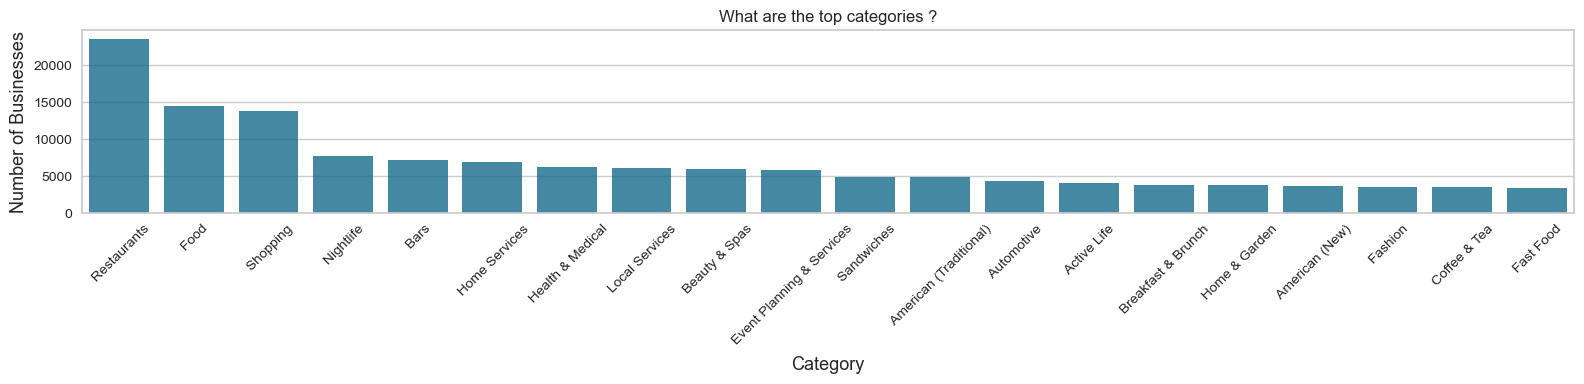

In [21]:
# Categories
cats = ''.join(df['categories'].astype('str'))
cats = pd.DataFrame(cats.split(','), columns = ['categories'])
x = cats.categories.value_counts()
x = x.sort_values(ascending = False)
x = x.iloc[0:20]

plt.figure(figsize = (16, 4))
sns.barplot(x = x.index, y = x.values, alpha = 0.8)
plt.title("What are the top categories ?")
locs, labels = plt.xticks()
plt.setp(labels, rotation=45)
plt.xlabel('Category', fontsize = 13)
plt.ylabel('Number of Businesses', fontsize = 13)
plt.tight_layout()
plt.show()

### Feature Engineering

### Clustering

#### 1. K-Means Clustering

#### 2. DBSCAN Clustering

#### 3. HDBSCAN Clustering

### Final Findings

*
* 